# 🎮 Video Game Sales Analysis
This project analyzes video game sales data to understand trends, patterns, and market behavior across different genres, consoles, and years.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 📂 Data Loading
The dataset is loaded using pandas and contains information about video games including genre, platform, sales, and critic scores.

In [20]:
data = pd.read_csv("Video_Games_Sales_Cleaned.csv")

### 🔍 Data Overview
We examine the structure of the dataset using:
- `head()` to view first rows
- `info()` to check data types and missing values
- `describe()` to understand statistical summary

In [21]:
data.head(10)

,title,console,genre,publisher,developer,critic_score,total_sales,release_year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,2013.0
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,2014.0
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,2002.0
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.3,15.86,2013.0
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,2015.0
5,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.7,14.82,2011.0
6,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.8,14.74,2010.0
7,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,2018.0
8,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,2012.0
9,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,2012.0


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18832 entries, 0 to 18831
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         18832 non-null  object 
 1   console       18832 non-null  object 
 2   genre         18832 non-null  object 
 3   publisher     18832 non-null  object 
 4   developer     18832 non-null  object 
 5   critic_score  18832 non-null  float64
 6   total_sales   18832 non-null  float64
 7   release_year  18832 non-null  float64
dtypes: float64(3), object(5)
memory usage: 1.1+ MB


In [23]:
data.describe(include="all")

,title,console,genre,publisher,developer,critic_score,total_sales,release_year
count,18832,18832,18832,18832,18832,18832.000000,18832.000000,18832.000000
unique,12935,39,20,739,2857,NaN,NaN,NaN
top,Open Season,DS,Action,Activision,Unknown,NaN,NaN,NaN
freq,9,2376,2825,1044,432,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,7.256611,0.350431,2007.686916
std,NaN,NaN,NaN,NaN,NaN,0.678515,0.809039,6.028529
min,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1977.000000
25%,NaN,NaN,NaN,NaN,NaN,7.300000,0.030000,2004.000000
50%,NaN,NaN,NaN,NaN,NaN,7.300000,0.120000,2008.000000
75%,NaN,NaN,NaN,NaN,NaN,7.300000,0.350000,2011.000000


### 🧹 Data Cleaning
The dataset is already cleaned:
- No missing values in important columns
- Release year is already extracted
- Data is ready for analysis

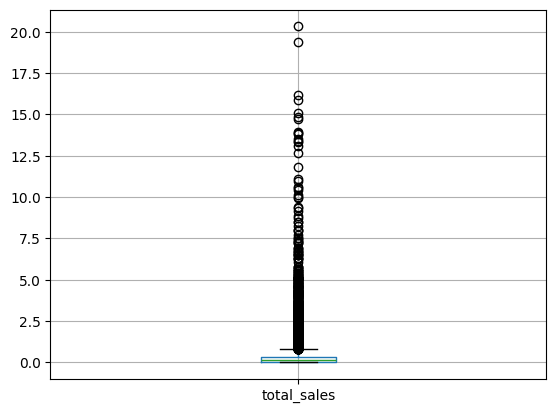

In [35]:
data.boxplot(column="total_sales")
plt.show()

### 🏆 Top Selling Games
This analysis identifies the highest selling video games globally.

In [24]:
top_games = data.sort_values("total_sales", ascending=False).head(10)
print(top_games[["title","total_sales"]])

                            title  total_sales
0              Grand Theft Auto V        20.32
1              Grand Theft Auto V        19.39
2     Grand Theft Auto: Vice City        16.15
3              Grand Theft Auto V        15.86
4       Call of Duty: Black Ops 3        15.09
5  Call of Duty: Modern Warfare 3        14.82
6         Call of Duty: Black Ops        14.74
7           Red Dead Redemption 2        13.94
8      Call of Duty: Black Ops II        13.86
9      Call of Duty: Black Ops II        13.80


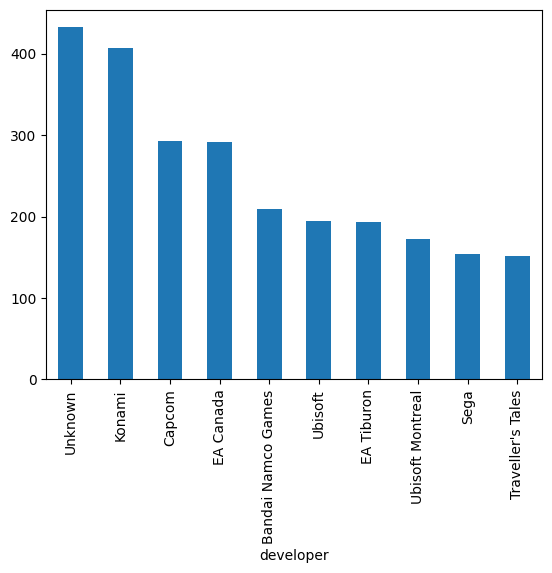

In [37]:
data["developer"].value_counts().head(10).plot(kind="bar")
plt.show()

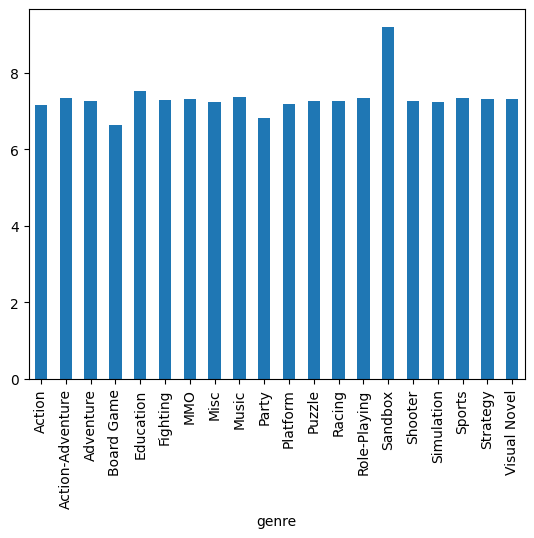

In [38]:
data.groupby("genre")["critic_score"].mean().plot(kind="bar")
plt.show()

### 🎯 Sales by Genre
This graph shows how different genres contribute to total sales.
It helps identify the most popular game categories.

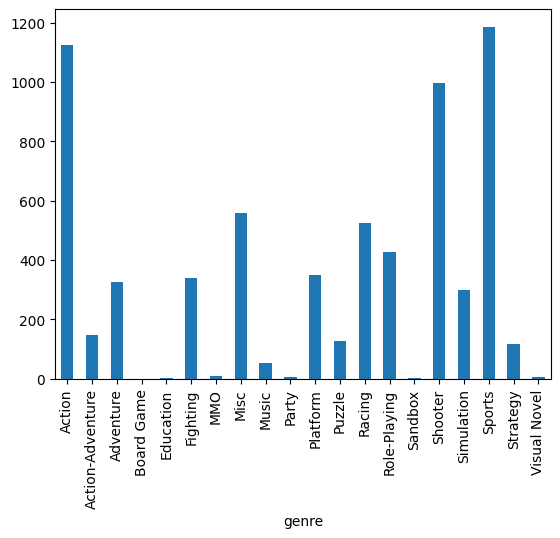

In [25]:
genre_sales = data.groupby("genre")["total_sales"].sum()
genre_sales.plot(kind="bar")
plt.show()

In [26]:
print(data[["critic_score","total_sales"]].corr())

              critic_score  total_sales
critic_score      1.000000     0.196856
total_sales       0.196856     1.000000


### 📊 Sales Distribution
Histogram shows that most games have low sales, while a few games have extremely high sales (outliers).

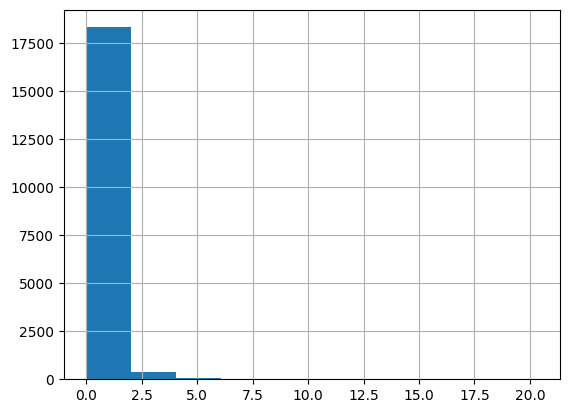

In [27]:
data["total_sales"].hist()
plt.show()

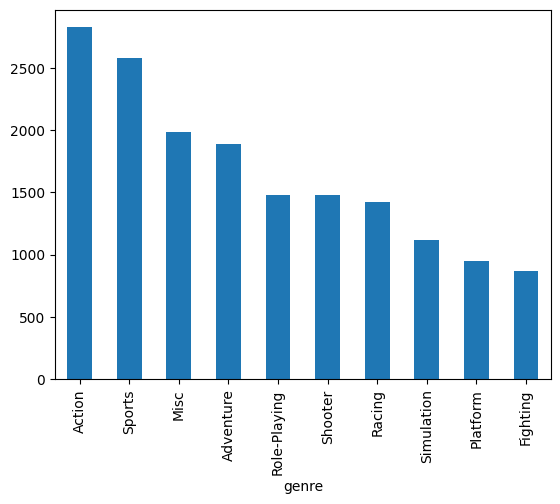

In [28]:
data["genre"].value_counts().head(10).plot(kind="bar")
plt.show()

### 🎮 Console Popularity
This chart shows which gaming platforms have the highest number of games.

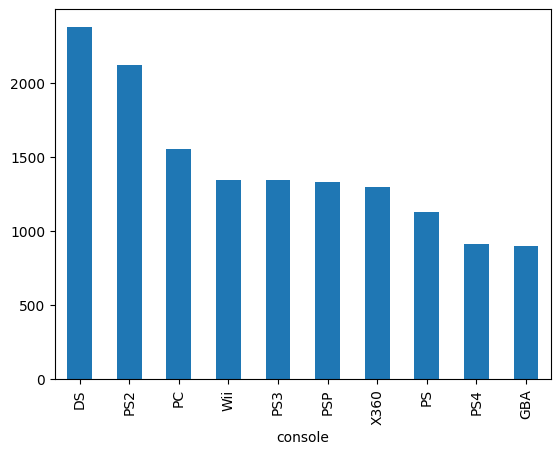

In [29]:
data["console"].value_counts().head(10).plot(kind="bar")
plt.show()

### ⭐ Critic Score vs Sales
Scatter plot shows relationship between critic ratings and sales.
Higher scores tend to slightly increase sales, but not strongly.

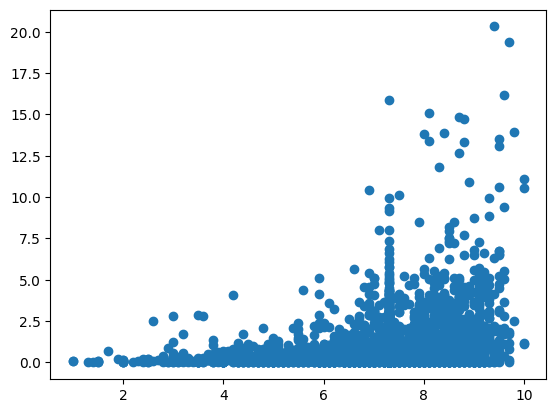

In [30]:
plt.scatter(data["critic_score"], data["total_sales"])
plt.show()

### 📈 Yearly Sales Trend
This graph shows how game releases have changed over time.
Peak growth is observed around mid-2000s.

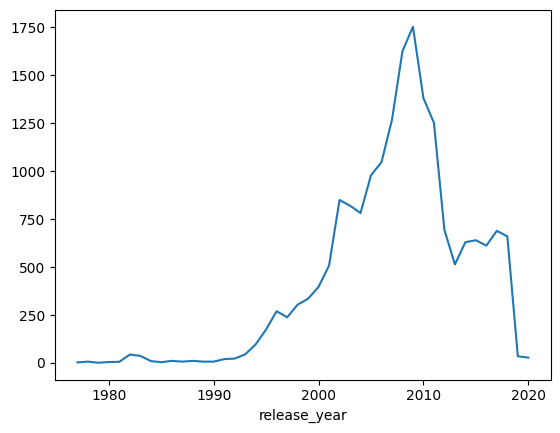

In [31]:
data["release_year"].value_counts().sort_index().plot()
plt.show()

### 🏢 Top Publishers
This analysis highlights companies that have published the most games.

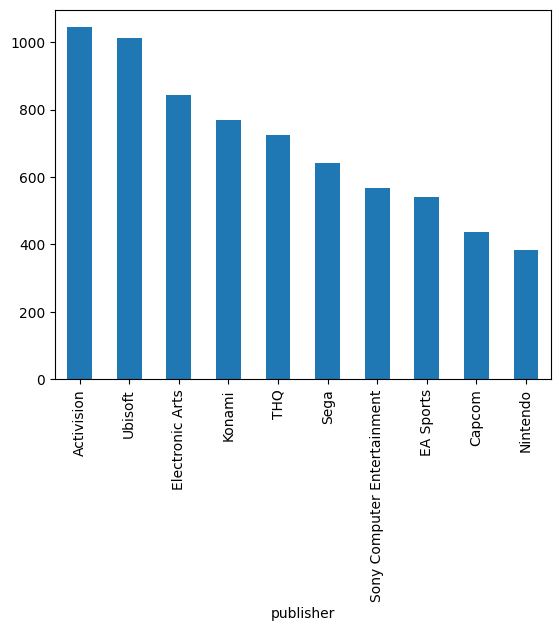

In [32]:
data["publisher"].value_counts().head(10).plot(kind="bar")
plt.show()

### 💰 Sales by Console
Shows which platforms generated the highest total sales.

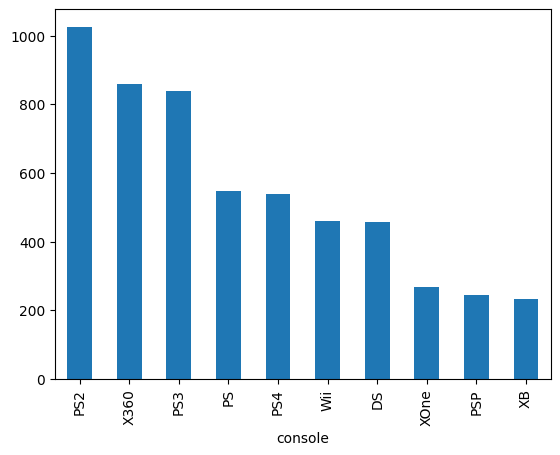

In [33]:
data.groupby("console")["total_sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.show()

### 📉 Genre Trends Over Time
This graph shows how popularity of different genres has changed over the years.

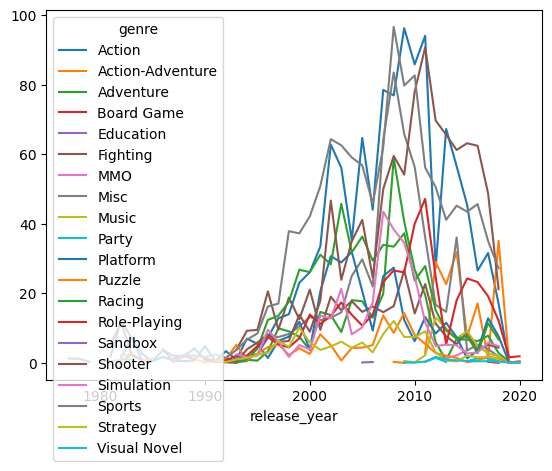

In [34]:
data.groupby(["release_year","genre"])["total_sales"].sum().unstack().plot()
plt.show()

### 🔥 Correlation Heatmap
This shows correlation between critic score and total sales.
The relationship is weak positive.

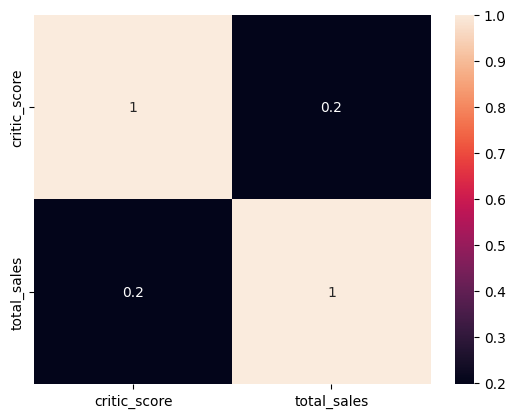

In [39]:
import seaborn as sns

sns.heatmap(data[["critic_score","total_sales"]].corr(), annot=True)
plt.show()

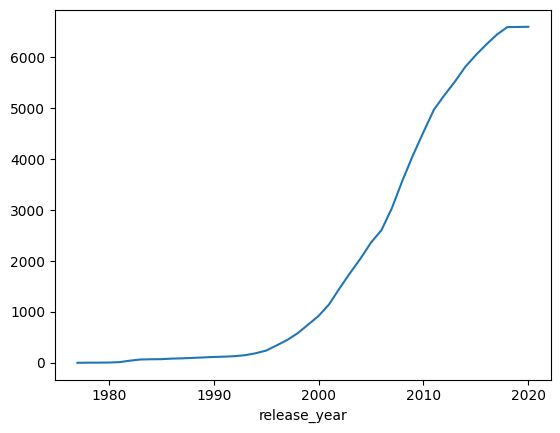

In [40]:
data.groupby("release_year")["total_sales"].sum().cumsum().plot()
plt.show()

## 🧠 Conclusion

- Action and Sports are the most popular genres
- Most games generate low sales, few become blockbusters
- Sales peaked around 2005–2010
- Critic scores have limited impact on sales
- Certain consoles dominate the market

This analysis helps understand gaming industry trends and consumer preferences.